In [32]:
# Load preprocessed training and validation datasets
# X_train and X_val contain feature variables after preprocessing
# y_train and y_val contain encoded readmission labels:
# 0 = No readmission, 1 = Readmission after 30 days, 2 = Readmission within 30 days

import pandas as pd

X_train = pd.read_csv("X_train.csv") 
X_val   = pd.read_csv("X_val.csv")

y_train = pd.read_csv("y_train.csv").squeeze()
y_val   = pd.read_csv("y_val.csv").squeeze()

train = pd.read_csv("diabetic_data_training.csv")
train.head()


print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)
print(y_train.value_counts())


(73271, 44) (18318, 44) (73271,) (18318,)
readmitted
0    39484
1    25591
2     8196
Name: count, dtype: int64


In [33]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

lr_baseline = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        
        solver="lbfgs",
        max_iter=2000
    ))
])


In [35]:
lr_baseline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncod...
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='object'))])),
                ('clf', LogisticRegression(max_iter=2000))])

In [36]:
# Logistic Regression is a linear classification model
# The multinomial setting is used to handle the three-class readmission problem
# The lbfgs solver is chosen as it is suitable for multinomial logistic regression

from sklearn.metrics import classification_report, confusion_matrix

pred = lr_baseline.predict(X_val)

print(classification_report(y_val, pred, digits=3))
print(confusion_matrix(y_val, pred))


              precision    recall  f1-score   support

           0      0.601     0.845     0.702      9871
           1      0.488     0.326     0.391      6398
           2      0.352     0.027     0.051      2049

    accuracy                          0.572     18318
   macro avg      0.480     0.399     0.381     18318
weighted avg      0.534     0.572     0.521     18318

[[8345 1487   39]
 [4251 2083   64]
 [1293  700   56]]


In [42]:
# Class weighting is applied to address class imbalance
# This increases the penalty for misclassifying minority classes,
# particularly early (<30 days) readmissions

lr_balanced = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced"
    ))
])

lr_balanced.fit(X_train, y_train)

pred_b = lr_balanced.predict(X_val)
print(classification_report(y_val, pred_b, digits=3))
print(confusion_matrix(y_val, pred_b))


              precision    recall  f1-score   support

           0      0.659     0.557     0.604      9871
           1      0.437     0.372     0.402      6398
           2      0.177     0.390     0.244      2049

    accuracy                          0.474     18318
   macro avg      0.424     0.440     0.417     18318
weighted avg      0.527     0.474     0.493     18318

[[5501 2442 1928]
 [2233 2383 1782]
 [ 618  631  800]]


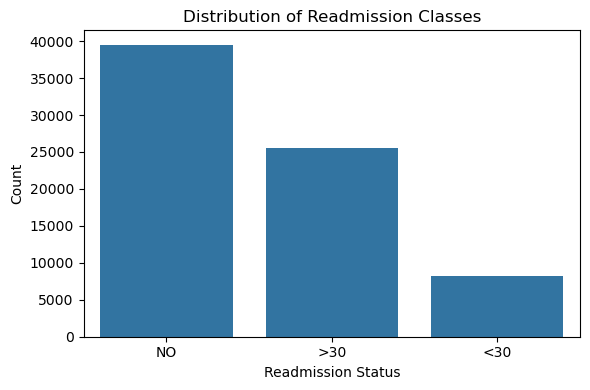

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.xticks([0,1,2], ["NO", ">30", "<30"])
plt.xlabel("Readmission Status")
plt.ylabel("Count")
plt.title("Distribution of Readmission Classes")
plt.tight_layout()
plt.show()


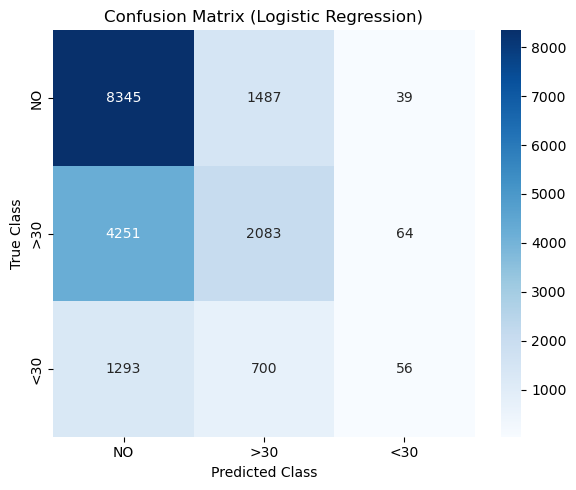

In [39]:
# The confusion matrix provides a detailed breakdown of model predictions
# It highlights misclassification patterns between different readmission classes

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
pred_lr = lr_baseline.predict(X_val)

#confusion matrix
cm_lr = confusion_matrix(y_val, pred_lr)

# draw  the matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NO", ">30", "<30"],
    yticklabels=["NO", ">30", "<30"]
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (Logistic Regression)")
plt.tight_layout()
plt.show()


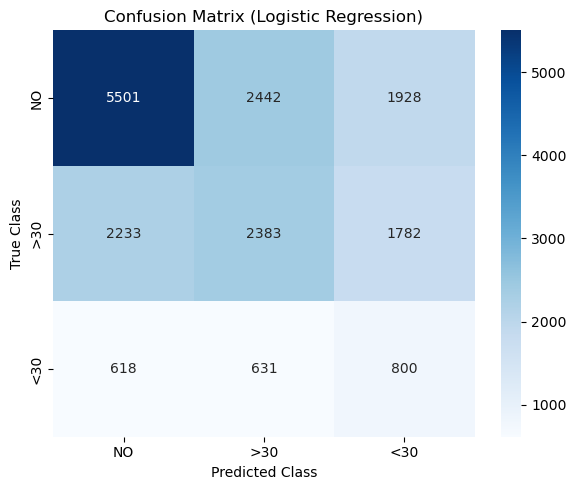

In [41]:
# The confusion matrix provides a detailed breakdown of model predictions
# It highlights misclassification patterns between different readmission classes

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
pred_lr = lr_balanced.predict(X_val)


#confusion matrix
cm_lr = confusion_matrix(y_val, pred_lr)

# draw  the matrix
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NO", ">30", "<30"],
    yticklabels=["NO", ">30", "<30"]
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (Logistic Regression)")
plt.tight_layout()
plt.show()

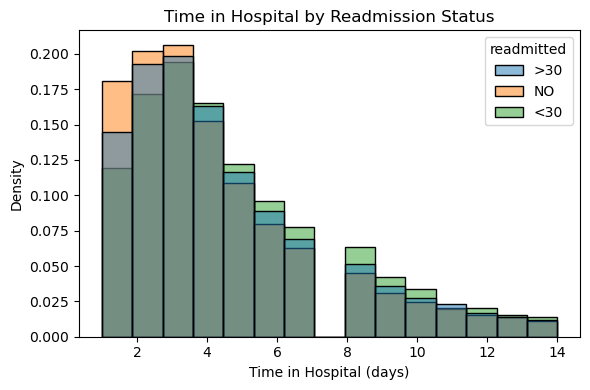

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(
    data=train,
    x="time_in_hospital",
    hue="readmitted",
    bins=15,
    stat="density",
    common_norm=False
)
plt.xlabel("Time in Hospital (days)")
plt.ylabel("Density")
plt.title("Time in Hospital by Readmission Status")
plt.tight_layout()
plt.show()


<Axes: xlabel='number_inpatient', ylabel='Density'>

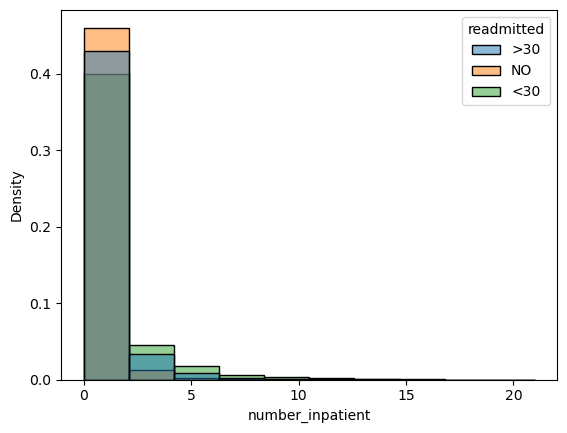

In [16]:
sns.histplot(
    data=train,
    x="number_inpatient",
    hue="readmitted",
    bins=10,
    stat="density",
    common_norm=False
)


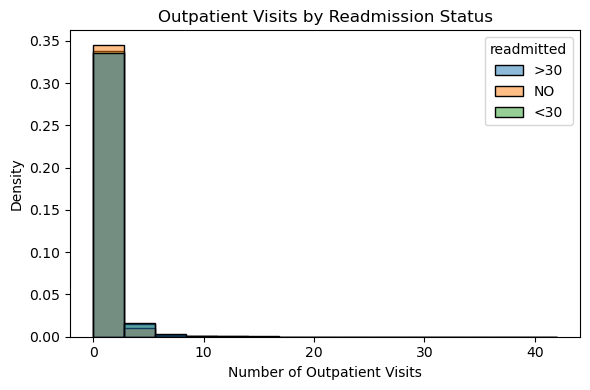

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(
    data=train,
    x="number_outpatient",
    hue="readmitted",
    bins=15,
    stat="density",
    common_norm=False
)
plt.xlabel("Number of Outpatient Visits")
plt.ylabel("Density")
plt.title("Outpatient Visits by Readmission Status")
plt.tight_layout()
plt.show()


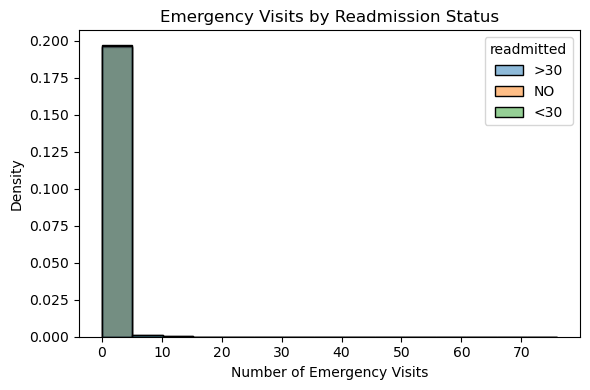

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(
    data=train,
    x="number_emergency",
    hue="readmitted",
    bins=15,
    stat="density",
    common_norm=False
)
plt.xlabel("Number of Emergency Visits")
plt.ylabel("Density")
plt.title("Emergency Visits by Readmission Status")
plt.tight_layout()
plt.show()


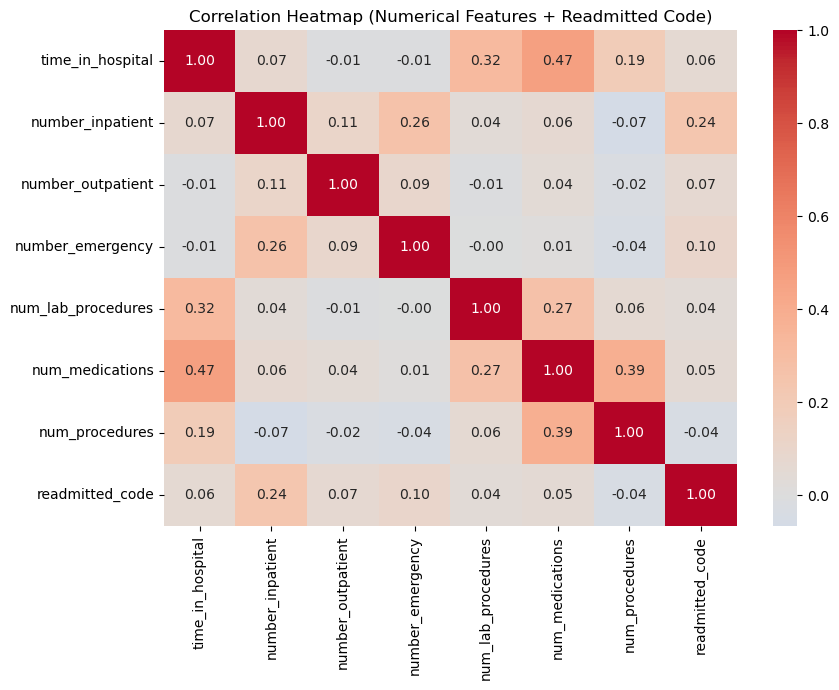

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    "time_in_hospital",
    "number_inpatient",
    "number_outpatient",
    "number_emergency",
    "num_lab_procedures",
    "num_medications",
    "num_procedures",
]

df_corr = train[num_cols + ["readmitted"]].copy()

df_corr["readmitted_code"] = df_corr["readmitted"].map({"NO": 0, ">30": 1, "<30": 2})

corr = df_corr[num_cols + ["readmitted_code"]].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features + Readmitted Code)")
plt.tight_layout()
plt.show()
